The pendulum motion can be described by the equation $\ddot{\theta} = -\frac{g}{l}\sin{}\theta$, where
- $g$ is the gravitational constant
- $l$ is the rope length
- $\theta$ is the angle of the rope with the vertical. 

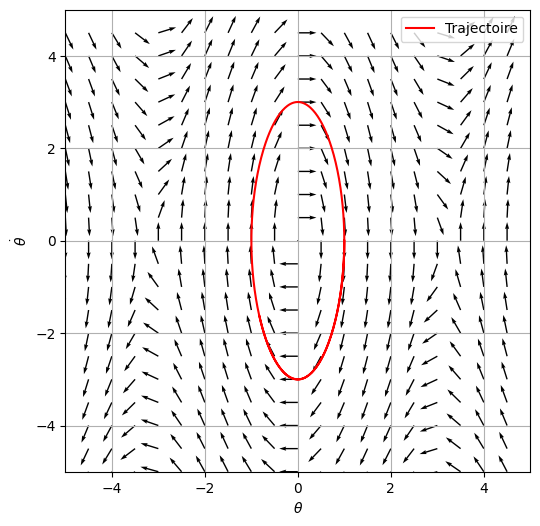

In [89]:
from scipy.integrate import solve_ivp

T_MAX = 3.0

def pendule(t, y, g, l):
    theta, theta_dot = y
    dtheta_dt = theta_dot
    dtheta_dot_dt = -(g / l) * np.sin(theta)
    return [dtheta_dt, dtheta_dot_dt]

def vecteurs_vitesse(g, l):
    theta, theta_dot = np.meshgrid(np.arange(-5, 5, 0.5), np.arange(-5, 5, 0.5))
    theta_values = theta_dot
    theta_dot_values = -(g / l) * np.sin(theta)
    norms = np.sqrt(theta_values**2 + theta_dot_values**2)
    norms[norms == 0] = 1
    theta_normalized = theta_values / norms
    theta_dot_normalized = theta_dot_values / norms
    vector_scale = 25
    plt.quiver(theta, theta_dot, theta_normalized, theta_dot_normalized, scale=vector_scale)
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$\dot{\theta}$")
    plt.xlim([-5, 5])
    plt.ylim([-5, 5])
    plt.grid()

g = 9.81
l = 1.0

plt.figure(figsize=(6, 6))
vecteurs_vitesse(g, l)

theta0 = 1.0
theta_dot0 = 0.0
t_span = (0, T_MAX)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(pendule, t_span, [theta0, theta_dot0], args=(g, l), t_eval=t_eval)

plt.plot(sol.y[0], sol.y[1], color='red', label="Trajectoire")
plt.legend()
plt.show()

In [90]:
class Model(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.l1 = nn.Linear(3, hidden)
        self.l2 = nn.Linear(hidden, hidden)
        self.l3 = nn.Linear(hidden, 1)
        self.activation = nn.Tanh()
        
    def forward(self, t, theta0, omega0):
        inp = torch.cat([t, theta0, omega0], dim=1)
        h = self.activation(self.l1(inp))
        h = self.activation(self.l2(h))
        nn_out = self.l3(h)
        theta = theta0 + omega0 * t + (t ** 2) * nn_out
        return theta

def loss_fn(t, theta0, omega0, model, g=9.81, l=1.0):
    t = t.clone().requires_grad_(True)
    theta = model(t, theta0, omega0)
    theta_t = torch.autograd.grad(theta, t, grad_outputs=torch.ones_like(theta), create_graph=True, retain_graph=True)[0]
    theta_tt = torch.autograd.grad(theta_t, t, grad_outputs=torch.ones_like(theta_t), create_graph=True, retain_graph=True)[0]
    residual = theta_tt + (g / l) * torch.sin(theta)
    physics_loss = torch.mean(residual ** 2)
    return physics_loss

n_epochs = 5000
n_points = 5000
model = Model()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for _ in (pbar := tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t = torch.rand((n_points, 1)) * T_MAX
    theta0 = (torch.pi * torch.rand((n_points, 1))) - torch.pi / 2
    omega0 = (torch.rand((n_points, 1)) * 2) - 1
    loss = loss_fn(t, theta0, omega0, model)
    pbar.set_description(f"Loss:{loss.item():.4e}")
    loss.backward()
    optimizer.step()

  0%|          | 0/5000 [00:00<?, ?it/s]

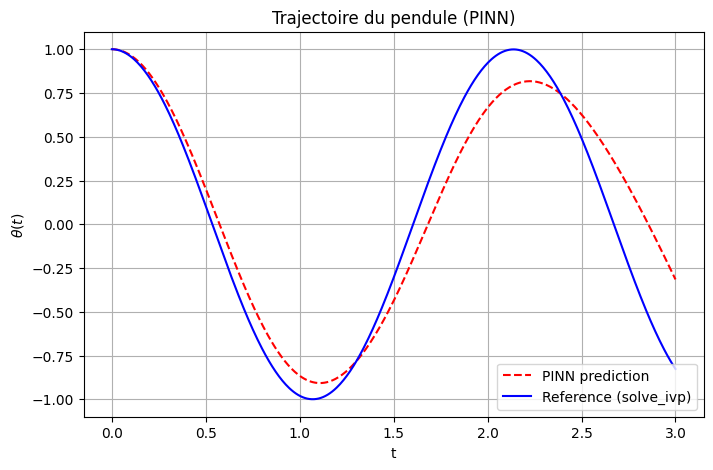

In [91]:
model.eval()
t_plot = torch.linspace(0, T_MAX, 500).unsqueeze(-1)
theta0 = torch.ones_like(t_plot)
omega0 = torch.zeros_like(t_plot)

with torch.no_grad():
    theta_pred = model(t_plot, theta0, omega0)

t_np = t_plot.cpu().numpy().flatten()
theta_np = theta_pred.cpu().numpy().flatten()

theta0 = 1.0
theta_dot0 = 0.0
g, l = 9.81, 1.0

sol = solve_ivp(pendule, (0, T_MAX), [theta0, theta_dot0], args=(g, l), t_eval=t_np, dense_output=True)

plt.figure(figsize=(8, 5))
plt.plot(t_np, theta_np, label="PINN prediction", color='red', linestyle='--')
plt.plot(sol.t, sol.y[0], label="Reference (solve_ivp)", color='blue')
plt.xlabel("t")
plt.ylabel(r"$\theta(t)$")
plt.title("Trajectoire du pendule (PINN)")
plt.grid()
plt.legend()
plt.show()

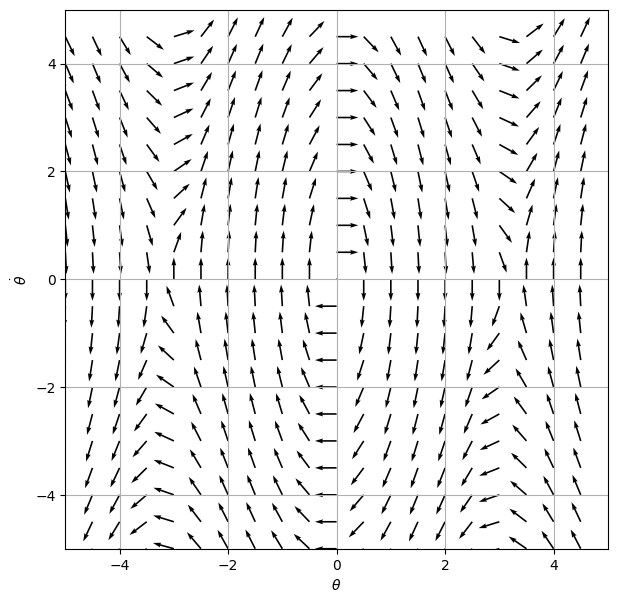

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# -----------------------------
# Phase portrait (true dynamics)
# -----------------------------
g = 9.81
l = 1.0

def vecteurs_vitesse(g, l):
    theta, omega = np.meshgrid(
        np.arange(-5, 5, 0.5),
        np.arange(-5, 5, 0.5)
    )

    dtheta = omega
    domega = -(g/l) * np.sin(theta)

    norm = np.sqrt(dtheta**2 + domega**2)
    norm[norm == 0] = 1

    plt.quiver(
        theta,
        omega,
        dtheta / norm,
        domega / norm,
        scale=25,
    )

    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$\dot{\theta}$")
    plt.xlim([-5,5])
    plt.ylim([-5,5])
    plt.grid()

plt.figure(figsize=(7,7))
vecteurs_vitesse(g, l)
plt.show()

In [69]:
%loadlibs
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


The pendulum motion can be described by the equation $\ddot{\theta} = -\frac{g}{l}\sin{}\theta$, where
- $g$ is the gravitational constant
- $l$ is the rope length
- $\theta$ is the angle of the rope with the vertical. 